In [ ]:
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.RobotController import RobotController
from optimal.configuration import UR10
import optimal.metrics as metrics
import numpy as np

type = UR10
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

def objective(trial, DT, path):
    # Ask Optuna to guess the weights (we use log scale because weights can vary wildly)
    # kp_1          = trial.suggest_float("kp_1",          1e-5, 1e5,  log=True)
    # kp_2          = trial.suggest_float("kp_2",          1e-5, 1e5,  log=True)
    # kp_3          = trial.suggest_float("kp_3",          1e-5, 1e5,  log=True)
    # kp_4          = trial.suggest_float("kp_4",          1e-5, 1e5,  log=True)
    # kp_5          = trial.suggest_float("kp_5",          1e-5, 1e5,  log=True)
    # kp_6          = trial.suggest_float("kp_6",          1e-5, 1e5,  log=True)
    # kd_1          = trial.suggest_float("kd_1",          1e-5, 1e5,  log=True)
    # kd_2          = trial.suggest_float("kd_2",          1e-5, 1e5,  log=True)
    # kd_3          = trial.suggest_float("kd_3",          1e-5, 1e5,  log=True)
    # kd_4          = trial.suggest_float("kd_4",          1e-5, 1e5,  log=True)
    # kd_5          = trial.suggest_float("kd_5",          1e-5, 1e5,  log=True)
    # kd_6          = trial.suggest_float("kd_6",          1e-5, 1e5,  log=True)
    kp_body       = trial.suggest_float("kp_body",       1e-5, 1e5,  log=True)
    kp_wrist      = trial.suggest_float("kp_wrist",      1e-5, 1e5,  log=True)
    kd_body       = trial.suggest_float("kd_body",       1e-5, 1e5,  log=True)
    kd_wrist      = trial.suggest_float("kd_wrist",      1e-5, 1e5,  log=True)

    time_limit        = trial.suggest_int("time_limit",        100, 10000, log=True)

    # kp = np.array([kp_1, kp_2, kp_3, kp_4, kp_5, kp_6])
    # kd = np.array([kd_1, kd_2, kd_3, kd_4, kd_5, kd_6])
    kp = np.array([kp_body]*3 + [kp_wrist]*3)
    kd = np.array([kd_body]*3 + [kd_wrist]*3)

    # Initialize your controller
    controller = RobotController(robot_pin_model)
    xs, us = [], []   
    terminal_error = 0.0 
    
    try:
        nq = len(robot_pin_model.q_indices)
        nv = len(robot_pin_model.v_indices)
        current_q = path[0]
        current_v = np.zeros(nv)
        
        for i in range(1, len(path)):
            target_q = path[i]
            x_start = np.concatenate([current_q, current_v])
            x_goal  = np.concatenate([target_q, np.zeros(nv)])
            
            t_xs, t_us = controller.compute_control(x_start=x_start, 
                                                    x_goal=x_goal, 
                                                    T=time_limit, DT=DT, kp=kp, kd=kd,
                                                    option="pd")
            
            actual_q = t_xs[-1][:nq]
            actual_v = t_xs[-1][nq:]
            
            # terminal error evaluated at the end of each segment
            terminal_error += metrics.terminal_error(actual_q, target_q)
            
            xs.extend(t_xs)
            us.extend(t_us)
            current_q = actual_q
            current_v = actual_v
            
            # If the robot is already failing to reach intermediate targets, we could penalize early (optional)
            
    except Exception as e:
        # If the solver crashes (e.g. weights were numerically unstable), 
        # return a massive penalty so Optuna knows it was a bad guess.
        print(f"Solver failed with error: {e}")
        return float('inf')

    # --- Evaluate the Metric (How good was the result?) ---
    control_effort = metrics.thermal_energy(us, DT)
    torque_jerk = metrics.torque_jerk(us)
    mechanical_work = metrics.mechanical_work(us, xs, DT)
    peak_power = metrics.peak_power(us, xs, DT)
    
    # Notice we weigh terminal error heavily because missing the target is a failure.
    metric_score = (1e4 * terminal_error) + (.2 * control_effort) + (.2 * torque_jerk) + (.2 * mechanical_work) + (.1 * peak_power)
    
    # If the score is NaN (diverged), penalize it
    if np.isnan(metric_score):
        return float('inf')
        
    return metric_score


## One set of Params for entire trajectory

In [86]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]

# === Approach 1: Globally tune weights for the entire path ===
study = optuna.create_study(direction="minimize")
# 100 trials is a relatively good start for tuning 5 hyperparameters
study.optimize(lambda trial: objective(trial, DT, path), n_trials=500, show_progress_bar=True)

print("Best global parameters:", study.best_params)
print("Best global score:", study.best_value)

# Duplicate parameters for each segment so later code can just use params[i]
params = [study.best_params for _ in range(len(path) - 1)]

  0%|          | 0/500 [00:00<?, ?it/s]

Best trial: 386. Best value: 575700: 100%|██████████| 500/500 [01:05<00:00,  7.59it/s] 

Best global parameters: {'kp_body': 0.3155172993415162, 'kp_wrist': 0.8978354355586207, 'kd_body': 1.7589223220878312e-05, 'kd_wrist': 0.06679498875703331, 'time_limit': 1530}
Best global score: 575699.9491684738


## Individual sets of Params per segment

In [83]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]

# === Approach 2: Tune weights for each segment individually ===
# (Useful if some movements are short/precise and others are long sweeps)

params_per_segment = []
current_q = path[0]

for i in range(1, len(path)):
    print(f"--- Evaluating Path Segment {i}/{len(path)-1} ---")
    study = optuna.create_study(direction="minimize")
    
    # We create a sub-path of just the start (current_q) and target (path[i]).
    sub_path = [current_q, path[i]]
    func = lambda trial: objective(trial, DT, sub_path)
    
    study.optimize(func, n_trials=100, show_progress_bar=True)
    params_per_segment.append(study.best_params)
    print(f"Best score for segment {i}: {study.best_value}")
    
    # We assume the tuner successfully reaches the target (or very close),
    # so the next segment starts from the target position.
    current_q = path[i]

print("\n=== All Best Coefficients (Per Segment) ===")
for i, param in enumerate(params_per_segment):
    print(f"Segment {i+1}: {param}")

params = params_per_segment

# Uncomment below if you want the subsequent simulation cells to use per-segment params
# params = params_per_segment

--- Evaluating Path Segment 1/4 ---


Best trial: 47. Best value: 106403: 100%|██████████| 100/100 [00:02<00:00, 35.20it/s]  


Best score for segment 1: 106403.15844200733
--- Evaluating Path Segment 2/4 ---


Best trial: 42. Best value: 18441.9: 100%|██████████| 100/100 [00:02<00:00, 38.56it/s]


Best score for segment 2: 18441.855239536544
--- Evaluating Path Segment 3/4 ---


Best trial: 65. Best value: 36781.8: 100%|██████████| 100/100 [00:02<00:00, 35.66it/s] 


Best score for segment 3: 36781.84504011845
--- Evaluating Path Segment 4/4 ---


Best trial: 86. Best value: 76726.3: 100%|██████████| 100/100 [00:04<00:00, 23.42it/s] 

Best score for segment 4: 76726.28152319259

=== All Best Coefficients (Per Segment) ===
Segment 1: {'kp_body': 15.508968361079082, 'kp_wrist': 7.782594800606215, 'kd_body': 9.055100675266253, 'kd_wrist': 0.005290867107612358, 'time_limit': 690}
Segment 2: {'kp_body': 126.87347771437126, 'kp_wrist': 64.99543588611043, 'kd_body': 0.018471895233934815, 'kd_wrist': 0.0001711912743208662, 'time_limit': 211}
Segment 3: {'kp_body': 58.28880333315331, 'kp_wrist': 103.04422268620812, 'kd_body': 3.1952109161581563e-05, 'kd_wrist': 0.0041106399467713, 'time_limit': 140}
Segment 4: {'kp_body': 3.799141810564919, 'kp_wrist': 1.439110560762761, 'kd_body': 0.00010980389875325947, 'kd_wrist': 0.02528411594908477, 'time_limit': 1040}


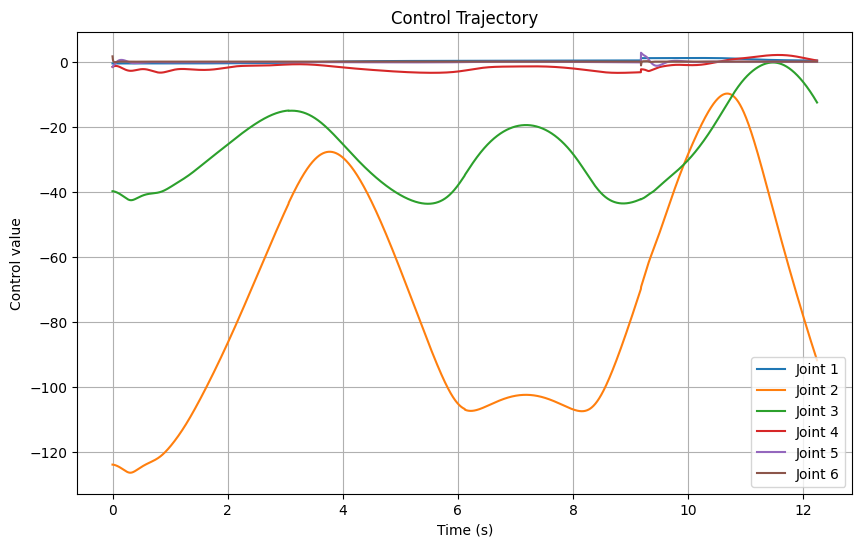

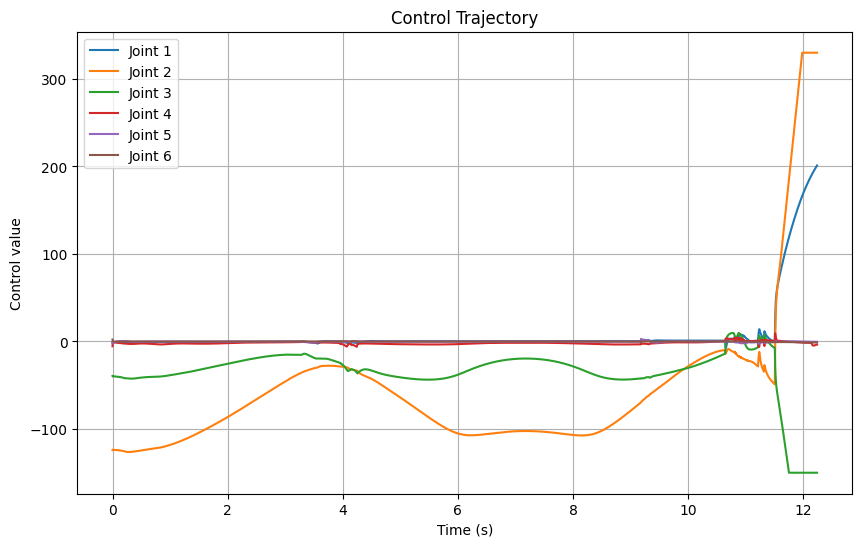

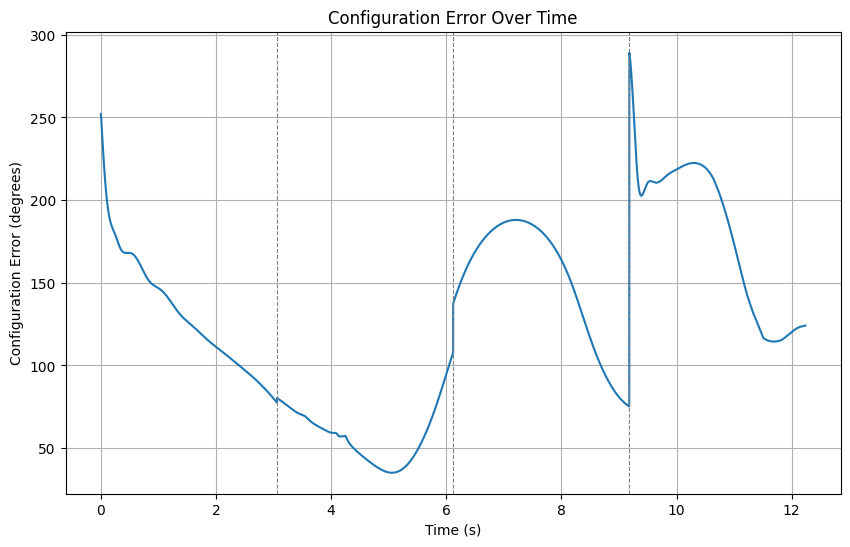

In [87]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox
from optimal.metrics import thermal_energy, mechanical_work, peak_power
import numpy as np

type = UR10_sandbox
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]
controller = RobotController(robot_pin_model)
xs, us = [], []
v_start = np.zeros(len(robot_pin_model.v_indices))
start = np.concatenate([path[0], v_start])
for i in range(len(path) - 1):
    # kp = np.array([params[i]["kp_1"], params[i]["kp_2"], params[i]["kp_3"], params[i]["kp_4"], params[i]["kp_5"], params[i]["kp_6"]])
    # kd = np.array([params[i]["kd_1"], params[i]["kd_2"], params[i]["kd_3"], params[i]["kd_4"], params[i]["kd_5"], params[i]["kd_6"]])
    kp= np.array([params[i]["kp_body"]]*3 + [params[i]["kp_wrist"]]*3)
    kd= np.array([params[i]["kd_body"]]*3 + [params[i]["kd_wrist"]]*3)
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                        x_goal=target, 
                                        T=params[i]["time_limit"], DT=DT,
                                        kp=kp,
                                        kd=kd,
                                        option="pd")
    start = np.concatenate([t_xs[-1][:len(robot_pin_model.q_indices)], t_xs[-1][len(robot_pin_model.q_indices):]])
    xs.extend(t_xs)
    us.extend(t_us)
    v_start = xs[-1][len(robot_pin_model.q_indices):]  # Update v_start for the next segment

xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
# xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
# xs_real, us_real = robot_mj_model.simulate_control(us=us)
# xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=type.kp, kd=type.kd)
# xs_real, us_real = robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
robot_mj_model.plot_controls(us, dt=DT)
robot_mj_model.plot_controls(us_real, dt=DT)
lengths = [param["time_limit"] for param in params]
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=lengths, dt=DT)

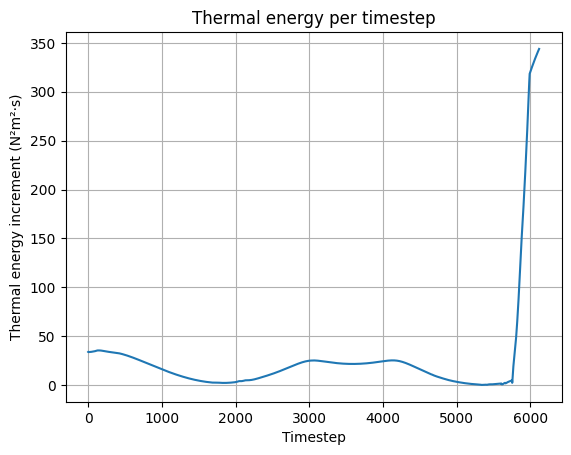

Thermal energy: 164293.04637132544


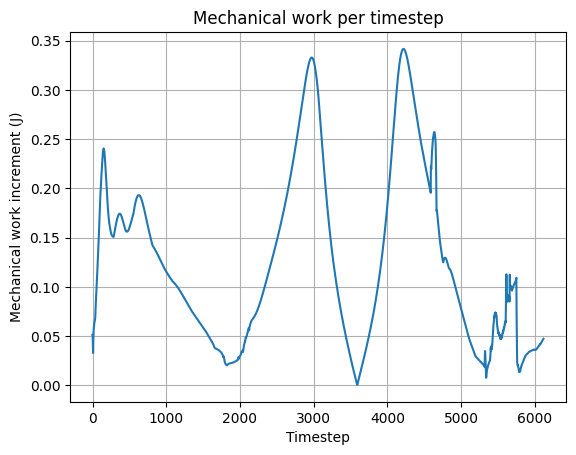

Mechanical work: 766.6544839480822


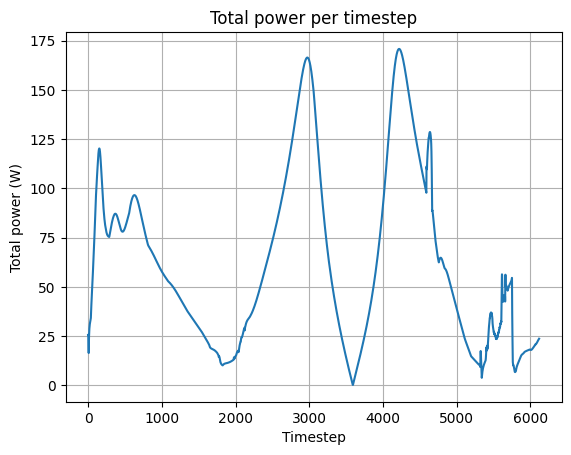

Peak power: 170.81648326150105


In [88]:
from optimal.metrics import thermal_energy, mechanical_work, peak_power

E_th  = thermal_energy(us_real, DT, True)
print("Thermal energy:", E_th)
E_mech = mechanical_work(us_real, xs_real, DT, True)
print("Mechanical work:", E_mech)
P_peak = peak_power(us_real, xs_real, True)
print("Peak power:", P_peak)

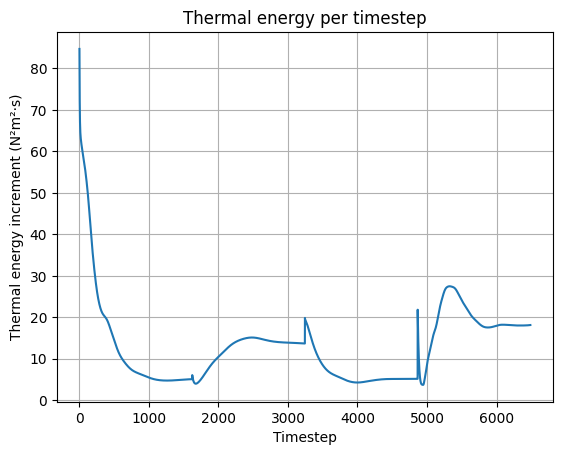

Thermal energy: 85024.00511528635


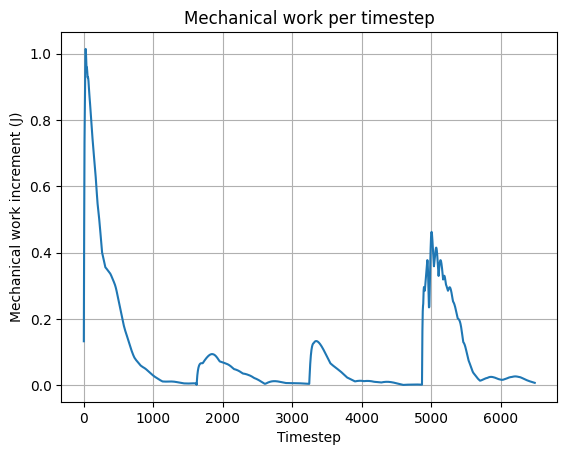

Mechanical work: 637.7911641473247


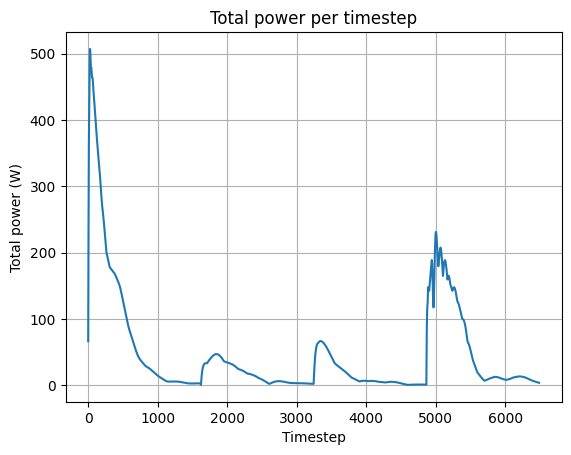

Peak power: 507.2076885790811


In [67]:
E_th  = thermal_energy(us, DT, True)
print("Thermal energy:", E_th)
E_mech = mechanical_work(us, xs, DT, True)
print("Mechanical work:", E_mech)
P_peak = peak_power(us, xs, True)
print("Peak power:", P_peak)